# Solar Power Generation Data: Classifier Test Base
## Solar power generation and sensor data for two power plants.

Description
This data has been gathered at two solar power plants in India over a 34 day period. It has two pairs of files - each pair has one power generation dataset and one sensor readings dataset. The power generation datasets are gathered at the inverter level - each inverter has multiple lines of solar panels attached to it. The sensor data is gathered at a plant level - single array of sensors optimally placed at the plant.

There are a few areas of concern at the solar power plant -

- Can we predict the power generation for next couple of days? - this allows for better grid management
- Can we identify generation profiles?
- Can we identify the need for panel cleaning/maintenance?
- Can we identify faulty or suboptimally performing equipment?

[Link to source](https://www.kaggle.com/anikannal/solar-power-generation-data)

In [258]:
import sys  

sys.path.append('../')

In [268]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

from read import (
    sourcesGen01Cleaned,
    groupsWeather01Cleaned,
)


## Data


In [260]:
X = groupsWeather01Cleaned["IRRADIATION"].T
y = sourcesGen01Cleaned["AC_POWER"][
    list(sourcesGen01Cleaned["AC_POWER"].keys())[0]
].T

x_train, x_test, y_train, y_test = train_test_split(
    X.values,
    y.values,
    test_size=0.20,
    shuffle=False
)
y_train, y_test = y_train.astype(int), y_test.astype(int)

print("X.shape = {}".format(X.shape))
print("y.shape = {}".format(y.shape))
print("x_train.shape = {}".format(x_train.shape))
print("y_train.shape = {}".format(y_train.shape))
print("x_test.shape = {}".format(x_test.shape))
print("y_test.shape = {}".format(y_test.shape))

X.shape = (34, 93)
y.shape = (34, 93)
x_train.shape = (27, 93)
y_train.shape = (27, 93)
x_test.shape = (7, 93)
y_test.shape = (7, 93)


In [261]:
def plot_original_data():
    plt.plot(x_train, y_train, 'o', color='red')
    plt.xlabel("IRRADIATION")
    plt.ylabel("AC_POWER")

def plot_predicted_data(pred):
    plt.plot(x_test, pred, 'o', color='blue')
    plt.legend(handles=[
        mpatches.Patch(color='red', label='Original data'),
        mpatches.Patch(color='blue', label='Predicted data'),
    ])

## KNN

Text(0.5, 1.0, 'KNN - Score 0.0')

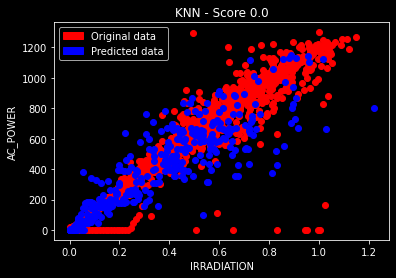

In [262]:
plot_original_data()

model = KNeighborsClassifier(n_neighbors=3)
clf = MultiOutputClassifier(model, n_jobs=-1)
clf.fit(x_train, y_train)

pred = clf.predict(x_test)
knnScore = clf.score(x_test, y_test)

plot_predicted_data(pred)
plt.title("KNN - Score {}".format(knnScore))


## NV

Text(0.5, 1.0, 'Naive Bayes - Score 0.0')

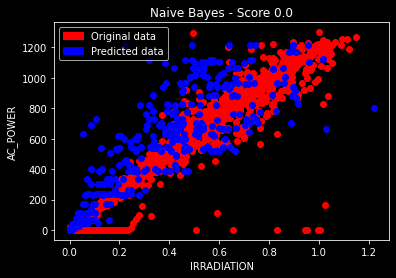

In [263]:
plot_original_data()

model = GaussianNB()
clf = MultiOutputClassifier(model, n_jobs=-1)
clf.fit(x_train, y_train)

pred = clf.predict(x_test)
naiveBayesScore = clf.score(x_test, y_test)

plot_predicted_data(pred)
plt.title("Naive Bayes - Score {}".format(naiveBayesScore))


## Decision Tree

Text(0.5, 1.0, 'Decision Tree - Score 0.0')

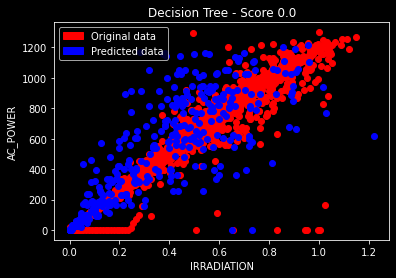

In [264]:
plot_original_data()

model = DecisionTreeClassifier(
    random_state=0, criterion="entropy", max_depth=100)
clf = MultiOutputClassifier(model, n_jobs=-1)
clf.fit(x_train, y_train)

pred = clf.predict(x_test)
treeScore = clf.score(x_test, y_test)

plot_predicted_data(pred)
plt.title("Decision Tree - Score {}".format(treeScore))


## MLP

Text(0.5, 1.0, 'MLP - Score 0.0')

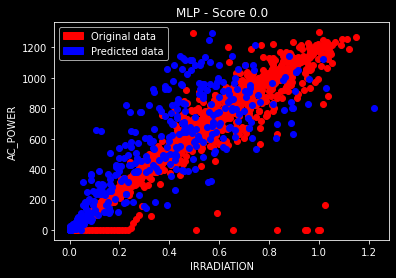

In [265]:
plot_original_data()

model = MLPClassifier(random_state=1,
                      max_iter=100000,
                      hidden_layer_sizes=(10, 10))
clf = MultiOutputClassifier(model, n_jobs=-1)
clf.fit(x_train, y_train)

pred = clf.predict(x_test)
mlpScore = clf.score(x_test, y_test)

plot_predicted_data(pred)
plt.title("MLP - Score {}".format(mlpScore))


## SVM

In [ ]:
plot_original_data()

model = make_pipeline(StandardScaler(), SVC(gamma='auto'))
clf = MultiOutputClassifier(model, n_jobs=-1)
clf.fit(x_train, y_train)

pred = clf.predict(x_test)
svmScore = clf.score(x_test, y_test)

plot_predicted_data(pred)
plt.title("SVM - Score {}".format(svmScore))


## AD

Text(0.5, 1.0, 'AD - Score 0.0')

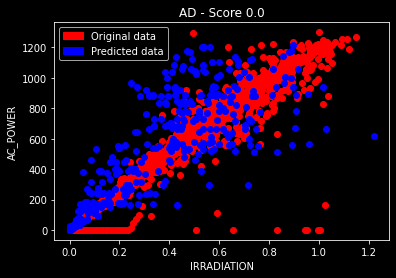

In [272]:
plot_original_data()

model = AdaBoostClassifier(n_estimators=100, random_state=0)
clf = MultiOutputClassifier(model, n_jobs=-1)
clf.fit(x_train, y_train)

pred = clf.predict(x_test)
adScore = clf.score(x_test, y_test)

plot_predicted_data(pred)
plt.title("AD - Score {}".format(adScore))


[0.0, 0.0, 0.0, 0.0, 0.0]


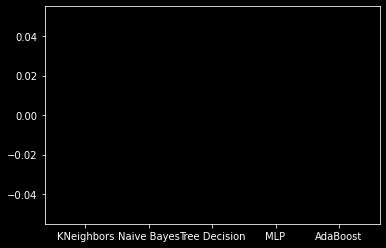

In [273]:
height = [knnScore, naiveBayesScore, treeScore, mlpScore, adScore]
bars = ('KNeighbors', 'Naive Bayes', 'Tree Decision', 'MLP', 'AdaBoost')
x_pos = np.arange(len(bars))
 
print(height)
plt.bar(x_pos, height)
plt.xticks(x_pos, bars)
plt.show()